In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [6]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,56,male,26.48,4,no,northwest,22543.60
1,46,female,28.81,5,yes,northeast,43180.49
2,32,male,25.45,3,no,northwest,-1708.98
3,60,male,30.20,4,no,southeast,34434.06
4,25,male,26.27,2,yes,southeast,38933.09


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 57.6+ KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,41.036622,29.834469,2.608371,25400.349529
std,13.528861,5.913797,1.675372,11899.695165
min,18.000000,9.170000,0.000000,-1708.980000
25%,29.000000,25.802500,1.000000,17219.065000
50%,42.000000,30.020000,3.000000,22479.545000
75%,52.000000,33.850000,4.000000,30141.297500
max,64.000000,46.390000,5.000000,60148.230000


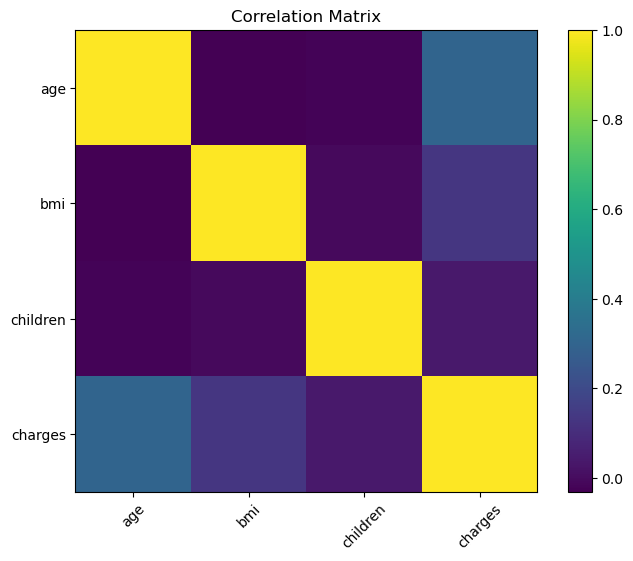

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

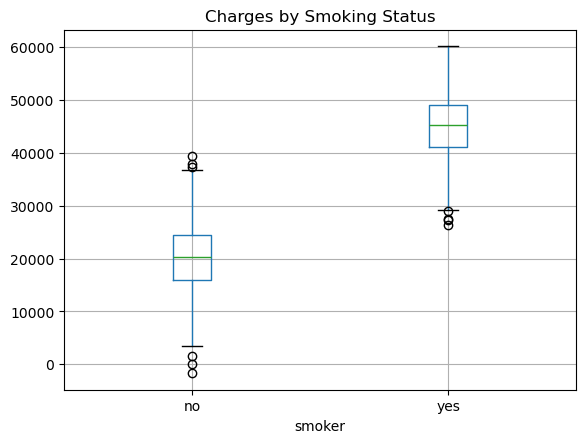

In [10]:
df.boxplot(column='charges', by='smoker')
plt.title("Charges by Smoking Status")
plt.suptitle("")
plt.show()

In [11]:
df["region_binary"] = df["region"].apply(
    lambda x: "north" if x in ["northeast", "northwest"] else "south"
)

In [12]:
np.random.seed(42)

train = df.sample(frac=0.7, random_state=42)
test = df.drop(train.index)

In [13]:
model = smf.ols(
    formula="charges ~ age + bmi + children + smoker + region_binary",
    data=train
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     867.9
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        10:00:57   Log-Likelihood:                -9315.5
No. Observations:                 937   AIC:                         1.864e+04
Df Residuals:                     931   BIC:                         1.867e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               1020

In [14]:
predictions = model.predict(test)

rmse = np.sqrt(np.mean((test["charges"] - predictions) ** 2))

print("RMSE:", rmse)

RMSE: 4989.353494216574
